# SETUP

In [2]:
!pip install evaluate rouge_score bert_score Sastrawi unsloth datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.2/403.2 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install -U bitsandbytes

In [ ]:
!pip install unsloth
!pip install transformers==4.57.0
!pip install --no-deps trl==0.26.2

In [1]:
!pip show unsloth transformers trl bitsandbytes

Name: unsloth
Version: 2026.4.1
Summary: 2-5X faster training, reinforcement learning & finetuning
Home-page: https://unsloth.ai
Author: Unsloth AI team
Author-email: info@unsloth.ai
License-Expression: Apache-2.0
Location: c:\users\lenovo\anaconda3\envs\kcvcapt\lib\site-packages
Requires: accelerate, bitsandbytes, datasets, diffusers, hf_transfer, huggingface_hub, nest-asyncio, numpy, packaging, peft, protobuf, psutil, pydantic, pyyaml, sentencepiece, torch, torchvision, tqdm, transformers, triton-windows, trl, typer, tyro, unsloth_zoo, wheel, xformers
Required-by: 
---
Name: transformers
Version: 4.57.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\users\lenovo\anaconda3

In [2]:
import pandas as pd
import numpy as np
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import re
from tqdm import tqdm
import os
import string
from collections import Counter
from functools import partial
from textwrap import wrap
import textwrap as tw
from warnings import filterwarnings
import gc
from io import BytesIO


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW, AdamW
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_


from unsloth import FastVisionModel, is_bfloat16_supported
from trl import SFTTrainer, SFTConfig, GRPOConfig, GRPOTrainer
from unsloth import UnslothVisionDataCollator

from torchvision.transforms import v2
from torchvision.models import inception_v3, Inception_V3_Weights, ResNet50_Weights, resnet50
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig, Seq2SeqTrainingArguments, Seq2SeqTrainer, GPT2Tokenizer, Dinov2Model, get_scheduler, AutoProcessor, AutoModelForCausalLM, BlipProcessor, BlipForConditionalGeneration
from peft import LoraConfig, get_peft_model

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

filterwarnings("ignore")
SEED=42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(SEED)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


c:\Users\LENOVO\anaconda3\envs\kcvcapt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0414 13:53:39.160000 2892 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!


# DATASET

## Kaggle Path

In [2]:
TRAIN_METADATA_PATH = "/kaggle/input/datasets/abidalfaridzi/metadata-vw/Train.csv"
VAL_METADATA_PATH = "/kaggle/input/datasets/abidalfaridzi/metadata-vw/Val.csv"
TEST_ANNOTATION_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/test.json"
TRAIN_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/train/train"
VAL_IMG_PATH = "/kaggle/input/datasets/frzzz090/vizwizz-ds/val/val"

## Local

In [ ]:
TRAIN_METADATA_PATH = "../data/Train.csv"
VAL_METADATA_PATH = "../data/Val.csv"
TEST_ANNOTATION_PATH = "../data/annotations/test.json"
TRAIN_IMG_PATH = "../data/train"
VAL_IMG_PATH = "../data/val"

In [ ]:
train_df = pd.read_csv(TRAIN_METADATA_PATH)
print(f"Number of training samples: {len(train_df)}")
display(train_df.head())

val_df = pd.read_csv(VAL_METADATA_PATH)
print(f"\nNumber of validation samples: {len(val_df)}")
display(val_df.head())

with open(TEST_ANNOTATION_PATH, "r") as f:
    test_data = json.load(f)
test_df = pd.DataFrame(test_data['images'])
print(f"\nNumber of test samples: {len(test_df)}")
display(test_df.head())

Number of training samples: 117155


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,0,False,False,0,True,INI ADALAH WADAH DAUN BASIL YANG MENUNJUKKAN B...
1,A green and white plastic condiment bottle con...,0,False,False,1,True,Botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,0,True,True,2,True,Masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,0,False,False,3,True,Sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,0,False,False,4,True,beberapa lembar daun basil dalam wadah di atas...



Number of validation samples: 38750


,caption,image_id,is_precanned,is_rejected,id,text_detected,caption_id
0,A computer screen shows a repair prompt on the...,23431,False,False,117155,True,Layar komputer menampilkan perintah perbaikan.
1,a computer screen with a repair automatically ...,23431,False,False,117156,True,Layar komputer dengan pesan perbaikan yang mun...
2,partial computer screen showing the need of re...,23431,False,False,117157,True,Sebagian layar komputer menunjukkan perlunya p...
3,Part of a computer monitor showing a computer ...,23431,False,False,117158,True,Bagian dari monitor komputer yang menampilkan ...
4,The top of a laptop with a blue background and...,23431,False,False,117159,True,Bagian atas laptop dengan latar belakang biru ...



Number of test samples: 8000


,file_name,vizwiz_url,id,text_detected
0,VizWiz_test_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31181,True
1,VizWiz_test_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31182,False
2,VizWiz_test_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31183,True
3,VizWiz_test_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31184,True
4,VizWiz_test_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,31185,True


In [14]:
unq_id = sorted([int(i.split("_")[2].split(".")[0]) for i in os.listdir(VAL_IMG_PATH)])
max_val_id = max(unq_id)
new_val_id = [i for i in range(max_val_id + 1) for j in range(5)]
val_df['image_id'] = new_val_id

In [6]:
print("Total missing value in train:")
display(train_df.isnull().sum())

print("\nTotal missing value in val:")
display(val_df.isnull().sum())

print("\nTotal missing value in test:")
display(test_df.isnull().sum())

Total missing value in train:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in val:


caption          0
image_id         0
is_precanned     0
is_rejected      0
id               0
text_detected    0
caption_id       0
dtype: int64


Total missing value in test:


file_name        0
vizwiz_url       0
id               0
text_detected    0
dtype: int64

In [7]:
print(f"Total duplicate in train: {train_df.duplicated().sum()}")
print(f"Total duplicate in val: {val_df.duplicated().sum()}")
print(f"Total duplicate in test: {val_df.duplicated().sum()}")

Total duplicate in train: 0
Total duplicate in val: 0
Total duplicate in test: 0


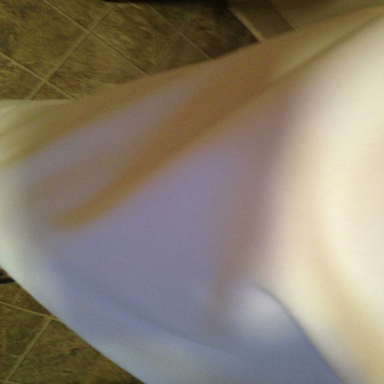

In [9]:
def display_single_image(image_id):
    image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{image_id:08d}.jpg")
    image = Image.open(image_path).resize((384, 384))
    display(image)
display_single_image(train_df.loc[train_df['image_id'] == 15, 'image_id'].values[0])

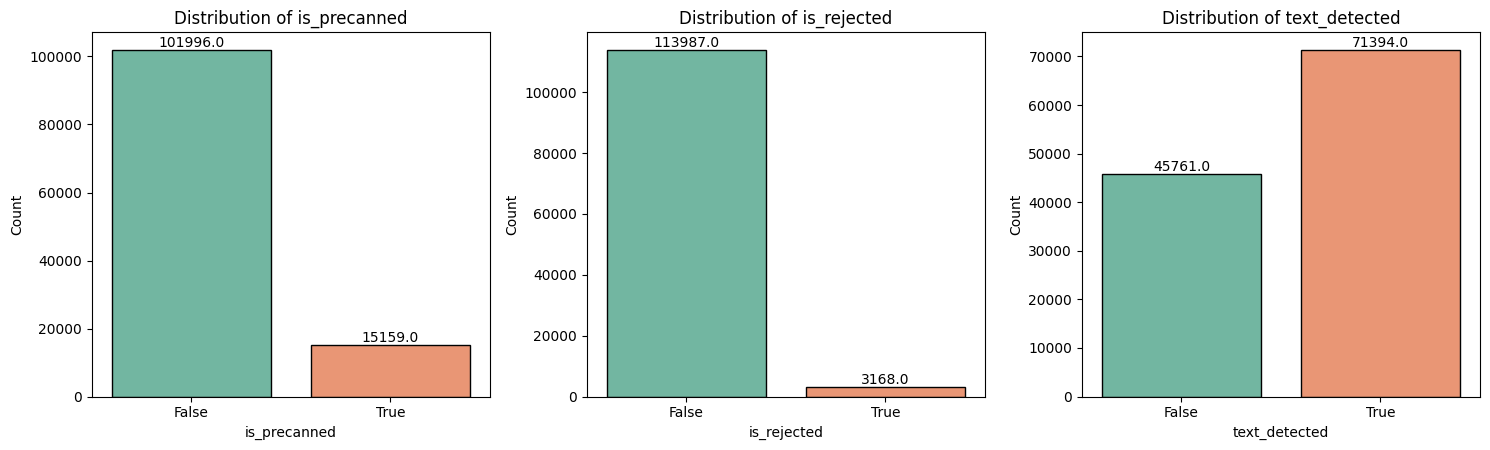

In [ ]:
def cols_distribution(df, columns):
    length = len(columns)
    cols = 3
    rows = length // cols + (length % cols > 0)
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, col in enumerate(columns):
        plt.subplot(rows, cols, i + 1)
        ax =sns.countplot(x=col, data=df, palette='Set2', edgecolor='black')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
cols_distribution(train_df, ['is_precanned', 'is_rejected', 'text_detected'])

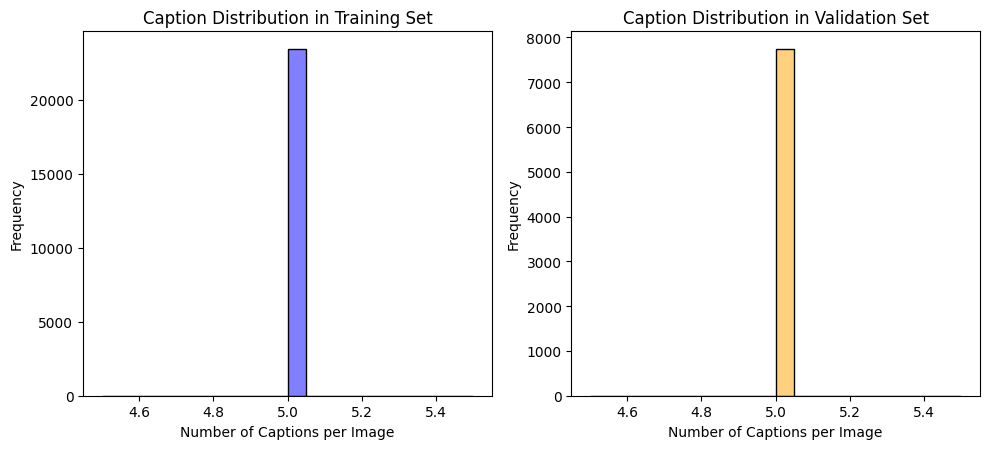

In [ ]:
def captions_distribution(train, val):
    cols, rows = 2, 1
    plt.figure(figsize=(5 * cols, 5 * rows))
    plt.subplot(rows, cols, 1)
    train_dist = train.groupby('image_id')['caption'].count()
    sns.histplot(train_dist, bins=20, kde=True, color='blue', edgecolor='black')
    plt.title("Caption Distribution in Training Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.subplot(rows, cols, 2)
    val_dist = val.groupby('image_id')['caption'].count()
    sns.histplot(val_dist, bins=20, kde=True, color='orange', edgecolor='black')
    plt.title("Caption Distribution in Validation Set")
    plt.xlabel("Number of Captions per Image")
    plt.ylabel("Frequency")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
captions_distribution(train_df, val_df)


=> every image has 5 captions

Image ID: 20952


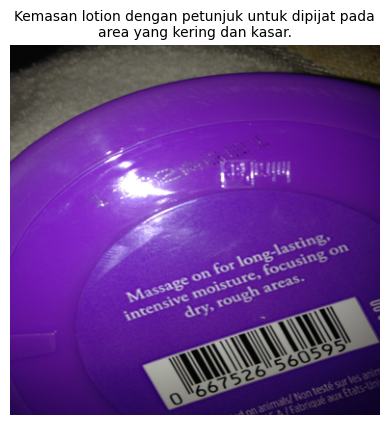

Image ID: 3648


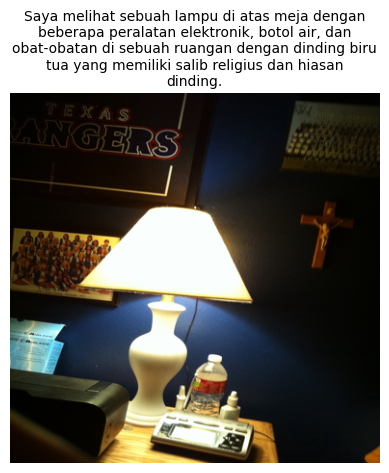

Image ID: 819


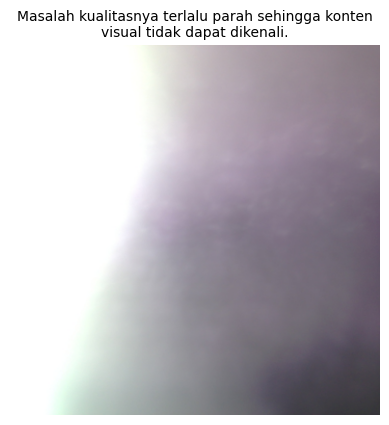

Image ID: 9012


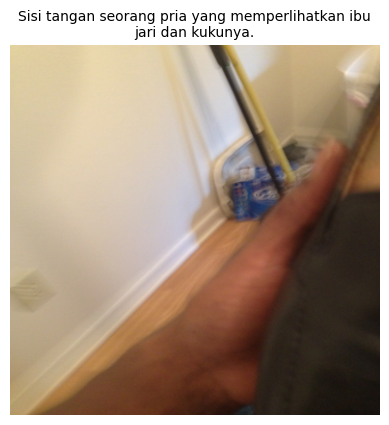

Image ID: 8024


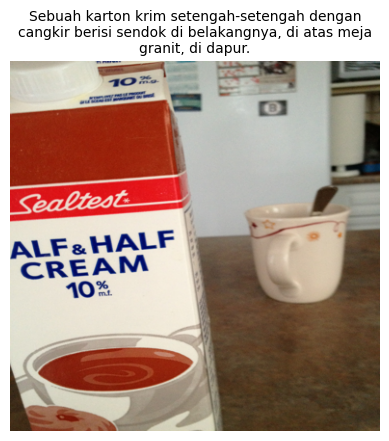

In [7]:
def display_image_captions(df, n_samples=5):
    random_idxs = random.sample(list(df['image_id'].unique()), n_samples)
    for idx in random_idxs:
        image_path = os.path.join(TRAIN_IMG_PATH, f"VizWiz_train_{idx:08d}.jpg")
        image = Image.open(image_path).resize((384, 384))
        captions = df[df['image_id'] == idx]['caption_id'].values[0]
        print(f"Image ID: {idx}")
        plt.imshow(image)
        plt.axis('off')
        plt.title("\n".join(wrap(captions, width=50)), fontsize=10)
        plt.show()
display_image_captions(train_df, n_samples=5)


In [15]:
def preprocess_caption(caption):
    caption = caption.lower()
    punc = string.punctuation.replace("'", "")
    caption = re.sub(f"[{re.escape(punc)}]", " ", caption)
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption
train_df['cleaned_caption'] = train_df['caption_id'].apply(preprocess_caption)
val_df['cleaned_caption'] = val_df['caption_id'].apply(preprocess_caption)
display(train_df[['caption', 'cleaned_caption']].head())

,caption,cleaned_caption
0,ITS IS A BASIL LEAVES CONTAINER ITS CONTAINS T...,ini adalah wadah daun basil yang menunjukkan b...
1,A green and white plastic condiment bottle con...,botol bumbu plastik berwarna hijau dan putih b...
2,Quality issues are too severe to recognize vis...,masalah kualitasnya terlalu parah sehingga kon...
3,A bottle of spices in a plastic container layi...,sebotol bumbu dalam wadah plastik tergeletak d...
4,some basil leaves in a container on a counter,beberapa lembar daun basil dalam wadah di atas...


In [16]:
train_df['image_id'] = train_df['image_id'].apply(lambda x: f"VizWiz_train_{x:08d}.jpg")
val_df['image_id'] = val_df['image_id'].apply(lambda x: f"VizWiz_val_{x:08d}.jpg")

In [17]:
max_len_train = train_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len_val = val_df['cleaned_caption'].apply(lambda x: len(x.split())).max()
max_len = max(max_len_train, max_len_val)
print(f"Max caption length in training set: {max_len_train}")
print(f"Max caption length in validation set: {max_len_val}")
print(f"Overall max caption length: {max_len}")

Max caption length in training set: 106
Max caption length in validation set: 145
Overall max caption length: 145


In [18]:
# pakai 1 img aj
grouped_captions_val = val_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
grouped_captions_train = train_df.groupby('image_id')['cleaned_caption'].apply(list).to_dict()
val_df = val_df.drop_duplicates(subset=['image_id']).reset_index(drop=True)
val_df.shape

(7750, 8)

In [10]:
def print_param(model, stage_name=""):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    all_params = sum(p.numel() for p in model.parameters())
    print(f"--- {stage_name} ---")
    print(f"Trainable params : {trainable_params:,}")
    print(f"Total params     : {all_params:,}")
    print(f"% Trainable      : {100 * trainable_params / all_params:.4f}%\n")

# MODEL

In [10]:
gc.collect()
torch.cuda.empty_cache()

### GRPO

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "../models/KevinLM3VL"

for var in ['model', 'tokenizer', 'trainer', 'optimizer']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm free memory before proceeding
free, total = torch.cuda.mem_get_info()
print(f"Free: {free/1024**3:.2f} GiB / Total: {total/1024**3:.2f} GiB")

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = CHECKPOINT_DIR,
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
    max_seq_length=4096,
    gpu_memory_utilization = 0.9,
)

Free: 6.77 GiB / Total: 7.96 GiB
==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [ ]:
from datasets import Dataset


REASONING_START = "<THINKING>"
REASONING_END = "</THINKING>"
CAPTION_START = "<CAPTION>"
CAPTION_END = "</CAPTION>"

BROKEN_FLAG = "masalah kualitasnya terlalu parah sehingga konten visual tidak dapat dikenali"
BROKEN_THRESHOLD = 4
MAX_IMAGE_SIZE = 336  


def format_reward_func(completions, **kwargs):
    scores = []
    for comp in completions:
        content = comp[0]["content"] if isinstance(comp, list) else comp
        has_caption  = len(re.findall(f'{CAPTION_START}(.*?){CAPTION_END}',  content, re.DOTALL)) == 1
        has_thinking = len(re.findall(f'{REASONING_START}(.*?){REASONING_END}', content, re.DOTALL)) == 1
        if has_caption and has_thinking:
            scores.append(1.0)
        elif has_caption:
            scores.append(0.5)
        else:
            scores.append(-1.0)
    return scores


def keyword_reward_func(completions, answer, **kwargs):
    scores = []
    for comp, true_ans in zip(completions, answer):
        content = comp[0]["content"] if isinstance(comp, list) else comp
        caption_match = re.search(f'{CAPTION_START}(.*?){CAPTION_END}', content, re.DOTALL)
        if not caption_match:
            scores.append(0.0)
            continue
        pred_caption = caption_match.group(1).lower()
        true_words    = set(true_ans.lower().split())
        pred_words    = set(pred_caption.split())
        overlap       = len(true_words & pred_words)
        scores.append((overlap / max(len(true_words), 1)) * 1.5)
    return scores



def select_best_caption(captions):
    return max(captions, key=lambda c: len(set(c.lower().split())))


def format_grpo_dataset(image_id, grouped_captions, image_dir):
    full_image_path = os.path.join(image_dir, image_id)
    broken_count = sum(1 for c in grouped_captions if BROKEN_FLAG in c)

    if broken_count >= BROKEN_THRESHOLD:
        final_caption = BROKEN_FLAG + "."
    else:
        valid = [c.strip().rstrip(".") for c in grouped_captions
                 if BROKEN_FLAG not in c and c.strip()]
        final_caption = select_best_caption(valid) + "."

    text_content = (
        "Deskripsikan gambar ini secara objektif untuk tunanetra. "
        f"Pertama, tuliskan analisis visual Anda di antara {REASONING_START} dan {REASONING_END}. "
        f"Setelah itu, berikan deskripsi akhir yang objektif, lengkap, dan siap dibacakan "
        f"oleh mesin TTS di antara {CAPTION_START} dan {CAPTION_END}."
    )

    return {
        "image_path": full_image_path,
        "answer": final_caption,
        "prompt_text": text_content,   # store text separately
    }


grpo_train_list = []
for image_id, captions in tqdm(grouped_captions_train.items(), desc="Formatting dataset"):
    grpo_train_list.append(format_grpo_dataset(image_id, captions, TRAIN_IMG_PATH))

hf_grpo_train = Dataset.from_list(grpo_train_list)



def resize_image(img: Image.Image, max_size: int = MAX_IMAGE_SIZE) -> Image.Image:
    """Resize keeping aspect ratio — critical for VRAM."""
    img.thumbnail((max_size, max_size), Image.LANCZOS)
    return img


def transform(batch):
    new_prompts = []

    for path, text in zip(batch["image_path"], batch["prompt_text"]):
        image = resize_image(Image.open(path).convert("RGB"))

        prompt = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text",  "text": text},
                ],
            }
        ]
        new_prompts.append(prompt)

    batch["prompt"] = new_prompts
    return batch


hf_grpo_train = hf_grpo_train.with_transform(transform)

half_epoch_steps2 = len(hf_grpo_train) // 16
print(f"~{half_epoch_steps2} steps for 0.5 epoch")

Formatting dataset:   0%|          | 0/23431 [00:00<?, ?it/s]

Formatting dataset: 100%|██████████| 23431/23431 [00:00<00:00, 124434.33it/s]


~1464 steps for 0.5 epoch


In [20]:
len(hf_grpo_train)

23431

In [ ]:
# model = FastVisionModel.get_peft_model(
#     model,
#     finetune_vision_layers = False,
#     finetune_language_layers = True,
#     finetune_attention_modules = True,
#     finetune_mlp_modules = False, # Matikan MLP untuk RL
#     r = 8,
#     lora_alpha = 16,
#     lora_dropout = 0,
#     bias = "none",
#     random_state = 3407,
# )
model.fine_tune_mlp_modules = False

FastVisionModel.for_training(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): Linear(in_features=1024, out_features=3072, bias=True)
                (proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (mlp): Qwen3VLVisionMLP(
                (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
               

In [ ]:
training_args = GRPOConfig(
    learning_rate=5e-6,
    optim="adamw_8bit",
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    warmup_steps=50,
    
    num_generations=2,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    max_prompt_length=512,
    max_completion_length=256,

    max_steps=half_epoch_steps2,  
    logging_steps=5,
    save_strategy="steps",
    save_steps=half_epoch_steps2,  
    
    output_dir="outputs/kevin_grpo1",

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    remove_unused_columns=False,
    dataloader_pin_memory=False,  
    dataloader_num_workers=0,    
)

trainer = GRPOTrainer(
    model=model,
    args=training_args,
    processing_class=tokenizer,

    reward_funcs=[
        format_reward_func,
        keyword_reward_func,
    ],

    train_dataset=hf_grpo_train,
)

trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 23,431 | Num Epochs = 1 | Total steps = 1,464
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,470,845,952 (0.74% trained)


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / keyword_reward_func / mean,rewards / keyword_reward_func / std
5,0.002500,-1.000000,0.000000,47.700000,21.600000,128.200000,0.025000,42.189286,21.600000,87.000000,2.499448,-1.000000,0.000000,0.000000,0.000000
10,0.002200,-0.882500,0.166170,62.550000,23.600000,160.600000,0.050000,53.666667,23.600000,146.800000,2.161627,-0.912500,0.247487,0.030000,0.084853
15,0.003200,-0.945000,0.077782,46.150000,22.800000,104.200000,0.000000,46.150000,22.800000,104.200000,3.238374,-0.950000,0.141421,0.005000,0.014142
20,0.002300,-0.881932,0.166974,47.125000,21.400000,115.200000,0.000000,47.125000,21.400000,115.200000,2.294792,-0.900000,0.282843,0.018068,0.051105
25,0.002000,-0.864904,0.191055,55.650000,23.400000,139.000000,0.000000,55.650000,23.400000,139.000000,2.011771,-0.900000,0.282843,0.035096,0.099267
30,0.002300,-0.654994,0.487912,95.450000,20.000000,231.600000,0.075000,83.167859,20.000000,171.800000,2.278198,-0.750000,0.609428,0.095006,0.232534
35,0.001600,-0.590268,0.400147,113.475000,39.200000,198.200000,0.125000,93.055000,39.200000,155.600000,1.645162,-0.650000,0.675026,0.059732,0.114970
40,0.001500,0.188671,0.914776,117.775000,68.200000,189.800000,0.025000,114.182144,68.200000,171.400000,1.466079,-0.037500,1.021812,0.226171,0.332291
45,0.001200,0.106251,0.822498,126.200000,62.800000,240.600000,0.150000,102.273573,62.800000,152.800000,1.186674,-0.062500,1.051548,0.168751,0.277894
50,0.001500,1.034841,0.552124,111.350000,58.200000,194.200000,0.025000,108.089287,58.200000,183.600000,1.539168,0.725000,0.524585,0.309841,0.329919


Unsloth: Will smartly offload gradients to save VRAM!


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: cc3dca20-6e33-4a0c-9838-75bf8ad1abec)')' thrown while requesting HEAD https://huggingface.co/unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit/resolve/main/config.json
[huggingface_hub.utils._http|WARNING]'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: cc3dca20-6e33-4a0c-9838-75bf8ad1abec)')' thrown while requesting HEAD https://huggingface.co/unsloth/Qwen3-VL-4B-Instruct-unsloth-bnb-4bit/resolve/main/config.json
Retrying in 1s [Retry 1/5].
[huggingface_hub.utils._http|WARNING]Retrying in 1s [Retry 1/5].


TrainOutput(global_step=1464, training_loss=0.0021980903922488577, metrics={'train_runtime': 55489.1531, 'train_samples_per_second': 0.211, 'train_steps_per_second': 0.026, 'total_flos': 0.0, 'train_loss': 0.0021980903922488577})

In [19]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = "../models/KevinLM3VLGRPO/checkpoint-1464"

for var in ['model', 'tokenizer', 'trainer', 'optimizer']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = CHECKPOINT_DIR,
    load_in_4bit = True,
    dtype = None,
)
FastVisionModel.for_inference(model)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(f"Model loaded on: {next(model.parameters()).device}")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory free: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    NVIDIA GeForce RTX 5050 Laptop GPU. Num GPUs = 1. Max memory: 7.96 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Model loaded on: cuda:0
GPU memory used: 4.14 GB
GPU memory free: 4.19 GB


In [20]:
REASONING_START = "<THINKING>"
REASONING_END   = "</THINKING>"
CAPTION_START   = "<CAPTION>"
CAPTION_END     = "</CAPTION>"

instruction = (
    "Deskripsikan gambar ini secara objektif untuk tunanetra. "
    f"Pertama, tuliskan analisis visual Anda di antara {REASONING_START} dan {REASONING_END}. "
    f"Setelah itu, berikan deskripsi akhir yang objektif, jelas,lengkap, dan siap dibacakan "
    f"oleh mesin TTS di antara {CAPTION_START} dan {CAPTION_END} dalam satu hingga dua kalimat."
)

def extract_caption(raw_output: str) -> str:
    match = re.search(f'{CAPTION_START}(.*?){CAPTION_END}', raw_output, re.DOTALL)
    if match:
        return match.group(1).strip()
    return raw_output.strip()

def extract_thinking(raw_output: str) -> str:
    match = re.search(f'{REASONING_START}(.*?){REASONING_END}', raw_output, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""

In [21]:
def compress_image(image_path, max_size=720, quality=85):
    image = Image.open(image_path).convert("RGB")

    image.thumbnail((max_size, max_size), Image.LANCZOS)

    buffer = BytesIO()
    image.save(buffer, format="JPEG", quality=quality, optimize=True)
    buffer.seek(0)
    compressed = Image.open(buffer).convert("RGB")

    print(f"Compressed size: {compressed.size}")
    return compressed

In [ ]:
def generate_caption(image_path, qwen_model, qwen_tokenizer, inst, max_gen_len=512):
    if isinstance(image_path, str):
        image = compress_image(image_path)
    else:
        image = image_path  

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": inst},
            ],
        }
    ]

    inputs_text = qwen_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    inputs = qwen_tokenizer(
        image,
        inputs_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        with autocast():
            generated_ids = qwen_model.generate(
                **inputs,
                max_new_tokens=max_gen_len,
                do_sample=False,
                num_beams=5,
                repetition_penalty=1.5,       
                no_repeat_ngram_size=4,       
            )

    input_len = inputs.input_ids.shape[1]
    generated_new_ids = generated_ids[:, input_len:]
    raw = qwen_tokenizer.batch_decode(generated_new_ids, skip_special_tokens=True)[0].strip()

    del inputs, generated_ids, generated_new_ids
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    return raw if raw else "unk"


Compressed size: (540, 720)
Thinking: Masalah kualitasnya terlalu parah sehingga konten visual tidak dapat dikenali. Gambar terlalu buram untuk mengenali apa pun di dalamnya. Tidak ada elemen visual yang dapat diperagakan kecuali beberapa cahaya yang memantul di sudut kanan bawah.
Caption (processed): Tidak ada gambar yang dapat dilihat, hanya latar belakang abu abu gelap dengan beberapa titik cahaya buram di sebelah kanan.
Compressed size: (540, 720)


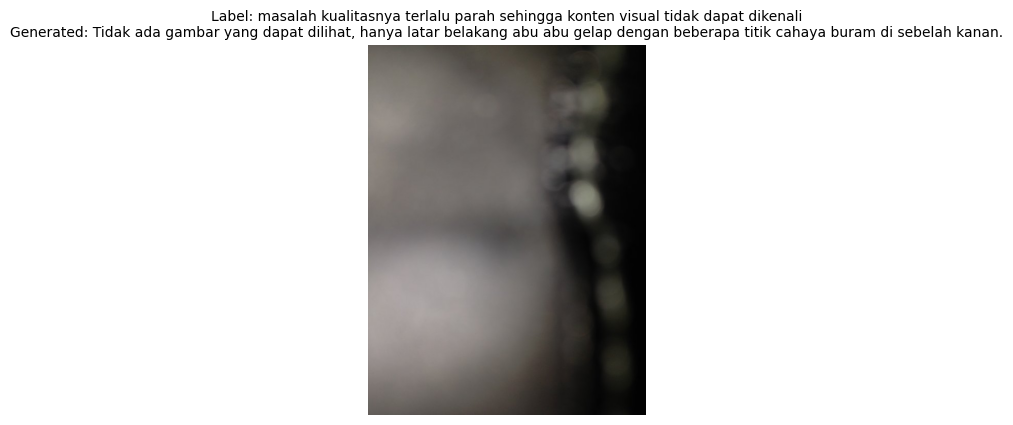

In [23]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

image_path = "../data/val/VizWiz_val_00007680.jpg"

with torch.inference_mode():
    caption_raw = generate_caption(image_path, model, tokenizer, instruction, max_gen_len=512)

thinking = extract_thinking(caption_raw)
print("Thinking:", thinking)
caption_processed = extract_caption(caption_raw)
print("Caption (processed):", caption_processed)

label = grouped_captions_val[os.path.basename(image_path)][0]
image_cp = compress_image(image_path)
plt.imshow(image_cp)
plt.axis("off")
plt.title(f"Label: {label}\nGenerated: {caption_processed}", fontsize=10)
plt.show()

del image_cp
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

Compressed size: (540, 720)
Thinking: Pada gambar ini terdapat lima pria yang mengenakan kemeja putih lengan pendek dan celana panjang. Mereka berdiri di bagian depan sebuah gedung besar dengan lantai marmer dan bangunan berbentuk segitiga di bagian belakang. Beberapa bangku kayu terlihat di sebelah kiri dan kanan mereka. Di bagian tengah belakang terdapat altar dengan patung yesus dan sebuah benda berwarna ungu yang tergantung di atasnya.
Caption (processed): lima pria mengenakan seragam putih berdiri bersama di sebuah gereja dengan latar belakang altar dan bangunan segitiga besar berwarna cokelat muda. Lantainya berubin marmer dan terdapat beberapa bangku di kedua sisi mereka.
Compressed size: (540, 720)


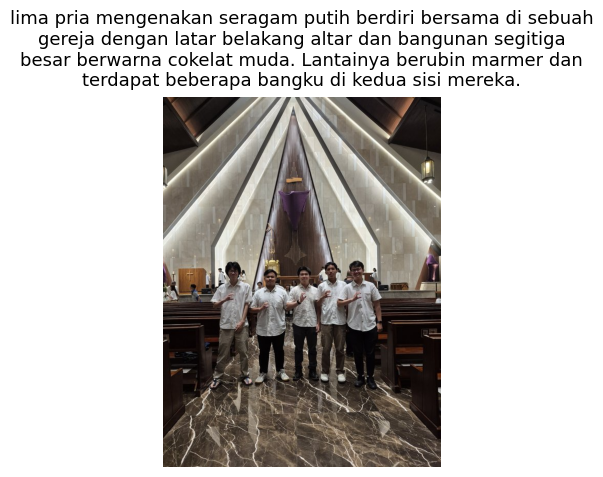

: 

In [ ]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

image_path = "../data/gereja.jpeg"

with torch.inference_mode():
    caption_raw = generate_caption(image_path, model, tokenizer, instruction, max_gen_len=512)

thinking = extract_thinking(caption_raw)
print("Thinking:", thinking)
caption_processed = extract_caption(caption_raw)
print("Caption (processed):", caption_processed)

image_cp = compress_image(image_path)
plt.imshow(image_cp)
plt.axis("off")
plt.title("\n".join(wrap(caption_processed, width=60)), fontsize=13, pad=8)
plt.show()

del image_cp
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

Compressed size: (728, 724)
Thinking: Gambar tersebut menunjukkan seorang pria yang mengenakan kostum joker dari film 'The Dark Knight', berdiri di sebuah stasiun kereta bawah tanah sambil memegang buket bunga. Kostumnya mencolok dengan setelan ungu bergaris, dasi oranye, dasi hijau, topi ungu, dan rambut hijau palsu. Wajahnya dicat dengan garis garis hitam di sekitar mata, bibir merah tebal, dan wajah putih. Ia juga mengenakan sarung tangan ungu. Di latar belakang terlihat beberapa orang lain di stasiun dan deretan rel kereta.
Caption (processed): seorang pria berpakaian joker sedang memegang karangan bunga di depan stasiun metro dengan beberapa orang lain yang berjalan di belakangnya.
Compressed size: (728, 724)


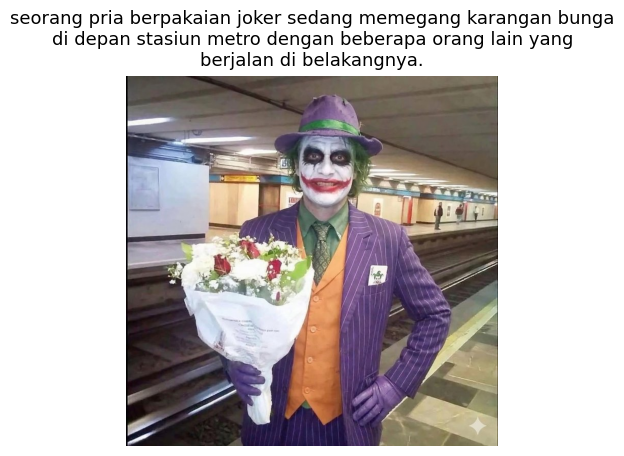

In [17]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

image_path = "../data/joker.png"


with torch.inference_mode():
    caption_raw = generate_caption(image_path, model, tokenizer, instruction, max_gen_len=512)

thinking = extract_thinking(caption_raw)
print("Thinking:", thinking)
caption_processed = extract_caption(caption_raw)
print("Caption (processed):", caption_processed)

image_cp = compress_image(image_path)
plt.imshow(image_cp)
plt.axis("off")
plt.title("\n".join(wrap(caption_processed, width=60)), fontsize=13, pad=8)
plt.show()

del image_cp
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

Compressed size: (728, 410)
Thinking: Gambar tersebut menunjukkan sebuah bangunan dengan tulisan teknik informatika di bagian atasnya. Bangunan tersebut terdiri dari beberapa lantai dan memiliki banyak jendela. Di sebelahnya terdapat bangunan lain yang lebih kecil. Kedua bangunan tersebut dikelilingi oleh pepohonan dan semak semak. Matahari terbenam di belakang bangunan yang lebih besar sehingga terjadi efek lens flare pada gambar.
Caption (processed): sebuah bangunan bertuliskan teknik informatika dengan bangunan lain di sebelah kiri dan pepohonan di sekitarnya. matahari terlihat di sisi kiri atas dengan sinar matahari menyilaukan.
Compressed size: (728, 410)


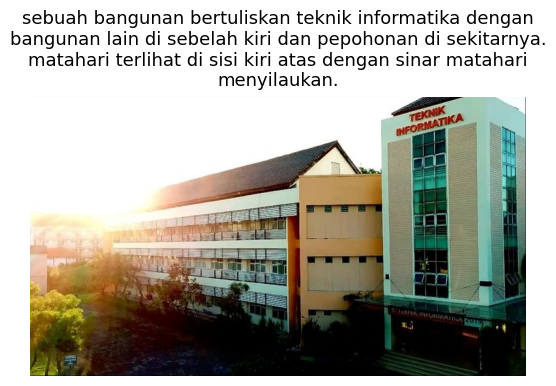

In [18]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

image_path = "../data/tc.jpg"
# image = Image.open(image_path).convert("RGB")
caption_raw = generate_caption(image_path, model, tokenizer, instruction, max_gen_len=256)
thinking = extract_thinking(caption_raw)
print("Thinking:", thinking)
caption_processed = extract_caption(caption_raw)
print("Caption (processed):", caption_processed)

image_cp = compress_image(image_path)
plt.imshow(image_cp)
plt.axis("off")
plt.title("\n".join(wrap(caption_processed, width=60)), fontsize=13, pad=8)
plt.show()

del image_cp
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()